In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = {
    "EmpId": [101, 102, "103", 104, 105, 106, 107, 108, 109, 110],
    "fullName": [
        "  Alice Johnson  ", "MICHEAL smith", "sarah lee", "David-Kim", None, "john brown",
        "Emma Wilson", "TOM  davis", "Jane Miller", "Chris taylor"
    ], 
     "Dept": ["IT", "hr", "Mktng", "IT", "Customer Care", "marketing", "Finance", None, "HR", "marketing"],
    "Age": [29, "thirty-five", 26, 31, 42, 27, 33, 30, None, 28],
    "Salary($)": ["$5500.50", "4800", "4200.75", "NaN", "6100", "4,300", "5800", "5000", "4700.0", "4400"],
    "JoinDate" : [ 
        "12-04-2021" , "2020.11.01" , "Jan 18, 2022" , "2019/9/25" , "07/05/18" , "2021-10-14" , 
        "2019/12/01" , "2020-03-22" , "May 10th, 2021" , "2022-02-05" 
    ],
    "Performance": [87, "73", 90, 65, 82, 75, 88, None, "79%", "91"],
    "Remote?": ["Yes", "No", "Y", "N", "yes", "no", "Y", "Yes", None, "True"]
}

In [4]:
#create a dataframe for the data
df = pd.DataFrame(data)

#convert the daraframe to csv file
df1 =  df.to_csv("employee_data.csv", index=False)

#load dataset
df = pd.read_csv("employee_data.csv")

df.head()


,EmpId,fullName,Dept,Age,Salary($),JoinDate,Performance,Remote?
0,101,Alice Johnson,IT,29,$5500.50,12-04-2021,87,Yes
1,102,MICHEAL smith,hr,thirty-five,4800,2020.11.01,73,No
2,103,sarah lee,Mktng,26,4200.75,"Jan 18, 2022",90,Y
3,104,David-Kim,IT,31,NaN,2019/9/25,65,N
4,105,NaN,Customer Care,42,6100,07/05/18,82,yes


In [5]:
#the shape 
df.shape

(10, 8)

In [6]:
#getting information on the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   EmpId        10 non-null     int64
 1   fullName     9 non-null      str  
 2   Dept         9 non-null      str  
 3   Age          9 non-null      str  
 4   Salary($)    9 non-null      str  
 5   JoinDate     10 non-null     str  
 6   Performance  9 non-null      str  
 7   Remote?      9 non-null      str  
dtypes: int64(1), str(7)
memory usage: 1.1 KB


In [7]:
#get columns from dataset
df.columns

Index(['EmpId', 'fullName', 'Dept', 'Age', 'Salary($)', 'JoinDate',
       'Performance', 'Remote?'],
      dtype='str')

In [8]:
#get missing value count
df.isnull().sum()

EmpId          0
fullName       1
Dept           1
Age            1
Salary($)      1
JoinDate       0
Performance    1
Remote?        1
dtype: int64

In [9]:
#get unique values columns
print(df["Dept"].unique())
print(df["Age"].unique())
print(df["Remote?"].unique())

<ArrowStringArray>
['IT', 'hr', 'Mktng', 'Customer Care', 'marketing', 'Finance', nan, 'HR']
Length: 8, dtype: str
<ArrowStringArray>
['29', 'thirty-five', '26', '31', '42', '27', '33', '30', nan, '28']
Length: 10, dtype: str
<ArrowStringArray>
['Yes', 'No', 'Y', 'N', 'yes', 'no', nan, 'True']
Length: 8, dtype: str


In [10]:
df["Salary($)"].head()

0    $5500.50
1        4800
2     4200.75
3         NaN
4        6100
Name: Salary($), dtype: str

In [11]:
#start cleaning incosistent values
#rename inconsistent columns
df.rename(columns={
    "EmpId": "Employee ID",
    "fullName": "Full Name",
    "Dept": "Department",
    "Salary($)": "Salary",
    "JoinDate": "Join Date",
    "Remote?": "Remote",
}, inplace=True)

df

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29,$5500.50,12-04-2021,87,Yes
1,102,MICHEAL smith,hr,thirty-five,4800,2020.11.01,73,No
2,103,sarah lee,Mktng,26,4200.75,"Jan 18, 2022",90,Y
3,104,David-Kim,IT,31,NaN,2019/9/25,65,N
4,105,NaN,Customer Care,42,6100,07/05/18,82,yes
5,106,john brown,marketing,27,"4,300",2021-10-14,75,no
6,107,Emma Wilson,Finance,33,5800,2019/12/01,88,Y
7,108,TOM davis,NaN,30,5000,2020-03-22,NaN,Yes
8,109,Jane Miller,HR,NaN,4700.0,"May 10th, 2021",79%,NaN
9,110,Chris taylor,marketing,28,4400,2022-02-05,91,True


In [12]:
#to display and check all values under a column
df["Full Name"] = (
    df["Full Name"]
    .str.strip()
    .str.title()
    .str.replace(r"[\s-]+", " ", regex=True)
    .tolist()
)
df["Full Name"].to_list()

['Alice Johnson',
 'Micheal Smith',
 'Sarah Lee',
 'David Kim',
 nan,
 'John Brown',
 'Emma Wilson',
 'Tom Davis',
 'Jane Miller',
 'Chris Taylor']

In [13]:
#clean inconsistent value in department
df.replace({
    "hr": "HR",
    "MKting": "Marketing",
    "marketing": "Marketing"
}, inplace=True)

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29,$5500.50,12-04-2021,87,Yes
1,102,Micheal Smith,HR,thirty-five,4800,2020.11.01,73,No
2,103,Sarah Lee,Mktng,26,4200.75,"Jan 18, 2022",90,Y
3,104,David Kim,IT,31,NaN,2019/9/25,65,N
4,105,NaN,Customer Care,42,6100,07/05/18,82,yes
5,106,John Brown,Marketing,27,"4,300",2021-10-14,75,no
6,107,Emma Wilson,Finance,33,5800,2019/12/01,88,Y
7,108,Tom Davis,NaN,30,5000,2020-03-22,NaN,Yes
8,109,Jane Miller,HR,NaN,4700.0,"May 10th, 2021",79%,NaN
9,110,Chris Taylor,Marketing,28,4400,2022-02-05,91,True


In [14]:
#clean inconsistent values in age
def clean_age(value):
    if value == "thirty-five":
        return 35
    elif isinstance(value, (int, float)):
        return value
    elif isinstance(value, str) and value.isdigit():
        return int(value)
    else:
        return np.nan
df["Age"] = df["Age"].apply(clean_age)

df["Age"]

0    29.0
1    35.0
2    26.0
3    31.0
4    42.0
5    27.0
6    33.0
7    30.0
8     NaN
9    28.0
Name: Age, dtype: float64

In [15]:
df

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,$5500.50,12-04-2021,87,Yes
1,102,Micheal Smith,HR,35.0,4800,2020.11.01,73,No
2,103,Sarah Lee,Mktng,26.0,4200.75,"Jan 18, 2022",90,Y
3,104,David Kim,IT,31.0,NaN,2019/9/25,65,N
4,105,NaN,Customer Care,42.0,6100,07/05/18,82,yes
5,106,John Brown,Marketing,27.0,"4,300",2021-10-14,75,no
6,107,Emma Wilson,Finance,33.0,5800,2019/12/01,88,Y
7,108,Tom Davis,NaN,30.0,5000,2020-03-22,NaN,Yes
8,109,Jane Miller,HR,NaN,4700.0,"May 10th, 2021",79%,NaN
9,110,Chris Taylor,Marketing,28.0,4400,2022-02-05,91,True


In [16]:
#clean inconsistent value in salary column
df["Salary"] = (
    df["Salary"]
    .astype(str)
    .replace('[$,]', "", regex=True)
    .replace("NaN", np.nan)
    .astype(float)
)

df["Salary"]

0    5500.50
1    4800.00
2    4200.75
3        NaN
4    6100.00
5    4300.00
6    5800.00
7    5000.00
8    4700.00
9    4400.00
Name: Salary, dtype: float64

In [17]:
from dateutil import parser

def clean_date(date_str):
    try:
        return parser.parse(date_str, dayfirst=True)
    except Exception:
         return pd.NaT

df["Join Date"] = df["Join Date"].apply(clean_date)
df["Join Date"]

0   2021-04-12
1   2020-01-11
2   2022-01-18
3   2019-09-25
4   2018-05-07
5   2021-10-14
6   2019-01-12
7   2020-03-22
8   2021-05-10
9   2022-05-02
Name: Join Date, dtype: datetime64[us]

In [18]:
df["Performance"] = (
    df["Performance"]
    .astype(str)
    .replace("%", "", regex=True)
    .replace("None", np.nan)
    .astype(float)
)

df["Performance"]

0    87.0
1    73.0
2    90.0
3    65.0
4    82.0
5    75.0
6    88.0
7     NaN
8    79.0
9    91.0
Name: Performance, dtype: float64

In [19]:
df.replace({
    "Y": "Yes",
    "N": "No",
    "yes": "Yes",
    "no": "No",
    "None": np.nan,
    "True": "Yes"
},inplace=True)

df["Remote"]

0    Yes
1     No
2    Yes
3     No
4    Yes
5     No
6    Yes
7    Yes
8    NaN
9    Yes
Name: Remote, dtype: str

In [20]:
df["Employee ID"] = pd.to_numeric(df["Employee ID"], errors="coerce")
df["Employee ID"]

0    101
1    102
2    103
3    104
4    105
5    106
6    107
7    108
8    109
9    110
Name: Employee ID, dtype: int64

In [21]:
#handling missing values
df["Full Name"] = df["Full Name"].fillna("Unknown")
df["Full Name"]

0    Alice Johnson
1    Micheal Smith
2        Sarah Lee
3        David Kim
4          Unknown
5       John Brown
6      Emma Wilson
7        Tom Davis
8      Jane Miller
9     Chris Taylor
Name: Full Name, dtype: str

In [22]:
df["Department"] = df["Department"].fillna(df["Department"].mode()[0])
df["Department"]

0               IT
1               HR
2            Mktng
3               IT
4    Customer Care
5        Marketing
6          Finance
7               HR
8               HR
9        Marketing
Name: Department, dtype: str

In [23]:
df["Age"] = df["Age"].fillna(df["Age"])
df["Age"]

0    29.0
1    35.0
2    26.0
3    31.0
4    42.0
5    27.0
6    33.0
7    30.0
8     NaN
9    28.0
Name: Age, dtype: float64

In [24]:
df["Salary"] = df["Salary"].fillna(df["Salary"].median())
df["Salary"]

0    5500.50
1    4800.00
2    4200.75
3    4800.00
4    6100.00
5    4300.00
6    5800.00
7    5000.00
8    4700.00
9    4400.00
Name: Salary, dtype: float64

In [25]:
df["Performance"] = df["Performance"].fillna(df["Performance"].median())
df["Performance"]

0    87.0
1    73.0
2    90.0
3    65.0
4    82.0
5    75.0
6    88.0
7    82.0
8    79.0
9    91.0
Name: Performance, dtype: float64

In [26]:
df["Remote"] = df["Remote"].fillna(df["Remote"].mode()[0])
df["Remote"]

0    Yes
1     No
2    Yes
3     No
4    Yes
5     No
6    Yes
7    Yes
8    Yes
9    Yes
Name: Remote, dtype: str

In [27]:
#working with filtering data

In [28]:
df["Full Name"]

0    Alice Johnson
1    Micheal Smith
2        Sarah Lee
3        David Kim
4          Unknown
5       John Brown
6      Emma Wilson
7        Tom Davis
8      Jane Miller
9     Chris Taylor
Name: Full Name, dtype: str

In [29]:
df[["Full Name", "Department", "Salary"]]

,Full Name,Department,Salary
0,Alice Johnson,IT,5500.50
1,Micheal Smith,HR,4800.00
2,Sarah Lee,Mktng,4200.75
3,David Kim,IT,4800.00
4,Unknown,Customer Care,6100.00
5,John Brown,Marketing,4300.00
6,Emma Wilson,Finance,5800.00
7,Tom Davis,HR,5000.00
8,Jane Miller,HR,4700.00
9,Chris Taylor,Marketing,4400.00


In [30]:
df.iloc[0:11, 0:3]

,Employee ID,Full Name,Department
0,101,Alice Johnson,IT
1,102,Micheal Smith,HR
2,103,Sarah Lee,Mktng
3,104,David Kim,IT
4,105,Unknown,Customer Care
5,106,John Brown,Marketing
6,107,Emma Wilson,Finance
7,108,Tom Davis,HR
8,109,Jane Miller,HR
9,110,Chris Taylor,Marketing


In [31]:
df.iloc[0:3]


,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes


In [32]:
df.loc[df["Salary"] >= 5000] #conditional statement

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,5500.5,2021-04-12,87.0,Yes
4,105,Unknown,Customer Care,42.0,6100.0,2018-05-07,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.0,2019-01-12,88.0,Yes
7,108,Tom Davis,HR,30.0,5000.0,2020-03-22,82.0,Yes


In [33]:
#df.loc(df["Salary"] >= 5000, ["Fullname"], ["Department"])

In [34]:
df.loc[:, "Salary"] #

0    5500.50
1    4800.00
2    4200.75
3    4800.00
4    6100.00
5    4300.00
6    5800.00
7    5000.00
8    4700.00
9    4400.00
Name: Salary, dtype: float64

In [35]:
df[df["Department"] == "IT"]

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,5500.5,2021-04-12,87.0,Yes
3,104,David Kim,IT,31.0,4800.0,2019-09-25,65.0,No


In [36]:
df[df["Age"] > 30]

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
1,102,Micheal Smith,HR,35.0,4800.0,2020-01-11,73.0,No
3,104,David Kim,IT,31.0,4800.0,2019-09-25,65.0,No
4,105,Unknown,Customer Care,42.0,6100.0,2018-05-07,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.0,2019-01-12,88.0,Yes


In [37]:
df[
    (df["Salary"] >= 5000) & (df["Department"] == "IT")
]

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,5500.5,2021-04-12,87.0,Yes


In [38]:
df[
    (df["Salary"] >= 4000) | (df["Remote"] == "Yes")
]

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes
3,104,David Kim,IT,31.0,4800.00,2019-09-25,65.0,No
4,105,Unknown,Customer Care,42.0,6100.00,2018-05-07,82.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No
6,107,Emma Wilson,Finance,33.0,5800.00,2019-01-12,88.0,Yes
7,108,Tom Davis,HR,30.0,5000.00,2020-03-22,82.0,Yes
8,109,Jane Miller,HR,NaN,4700.00,2021-05-10,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,2022-05-02,91.0,Yes


In [39]:
df[df["Department"].str.startswith("M")]

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No
9,110,Chris Taylor,Marketing,28.0,4400.00,2022-05-02,91.0,Yes


In [40]:
df[df["Department"].isin(["IT", "HR"])]

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,5500.5,2021-04-12,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.0,2020-01-11,73.0,No
3,104,David Kim,IT,31.0,4800.0,2019-09-25,65.0,No
7,108,Tom Davis,HR,30.0,5000.0,2020-03-22,82.0,Yes
8,109,Jane Miller,HR,NaN,4700.0,2021-05-10,79.0,Yes


In [41]:
df[df["Full Name"].str.contains("john", case=False)]

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,5500.5,2021-04-12,87.0,Yes
5,106,John Brown,Marketing,27.0,4300.0,2021-10-14,75.0,No


In [42]:
#working with sorting
df.sort_values("Salary", ascending=False)

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
4,105,Unknown,Customer Care,42.0,6100.00,2018-05-07,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,2019-01-12,88.0,Yes
0,101,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes
7,108,Tom Davis,HR,30.0,5000.00,2020-03-22,82.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No
3,104,David Kim,IT,31.0,4800.00,2019-09-25,65.0,No
8,109,Jane Miller,HR,NaN,4700.00,2021-05-10,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,2022-05-02,91.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes


In [43]:
df.sort_values("Performance", ascending=False)

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
9,110,Chris Taylor,Marketing,28.0,4400.00,2022-05-02,91.0,Yes
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,2019-01-12,88.0,Yes
0,101,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,2018-05-07,82.0,Yes
7,108,Tom Davis,HR,30.0,5000.00,2020-03-22,82.0,Yes
8,109,Jane Miller,HR,NaN,4700.00,2021-05-10,79.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No
1,102,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No
3,104,David Kim,IT,31.0,4800.00,2019-09-25,65.0,No


In [44]:
df.sort_values(["Department", "Salary"], ascending=False)

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,2022-05-02,91.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No
0,101,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes
3,104,David Kim,IT,31.0,4800.00,2019-09-25,65.0,No
7,108,Tom Davis,HR,30.0,5000.00,2020-03-22,82.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No
8,109,Jane Miller,HR,NaN,4700.00,2021-05-10,79.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,2019-01-12,88.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,2018-05-07,82.0,Yes


In [45]:
df.sort_values(["Department", "Salary"], ascending=[False, True])

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No
9,110,Chris Taylor,Marketing,28.0,4400.00,2022-05-02,91.0,Yes
3,104,David Kim,IT,31.0,4800.00,2019-09-25,65.0,No
0,101,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes
8,109,Jane Miller,HR,NaN,4700.00,2021-05-10,79.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No
7,108,Tom Davis,HR,30.0,5000.00,2020-03-22,82.0,Yes
6,107,Emma Wilson,Finance,33.0,5800.00,2019-01-12,88.0,Yes
4,105,Unknown,Customer Care,42.0,6100.00,2018-05-07,82.0,Yes


In [46]:
df["Department"].value_counts()

Department
HR               3
IT               2
Marketing        2
Mktng            1
Customer Care    1
Finance          1
Name: count, dtype: int64

In [47]:
df["Department"].value_counts(normalize=True)

Department
HR               0.3
IT               0.2
Marketing        0.2
Mktng            0.1
Customer Care    0.1
Finance          0.1
Name: proportion, dtype: float64

In [48]:
df["Remote"].value_counts(normalize=True)

Remote
Yes    0.7
No     0.3
Name: proportion, dtype: float64

In [49]:
df

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote
0,101,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes
1,102,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes
3,104,David Kim,IT,31.0,4800.00,2019-09-25,65.0,No
4,105,Unknown,Customer Care,42.0,6100.00,2018-05-07,82.0,Yes
5,106,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No
6,107,Emma Wilson,Finance,33.0,5800.00,2019-01-12,88.0,Yes
7,108,Tom Davis,HR,30.0,5000.00,2020-03-22,82.0,Yes
8,109,Jane Miller,HR,NaN,4700.00,2021-05-10,79.0,Yes
9,110,Chris Taylor,Marketing,28.0,4400.00,2022-05-02,91.0,Yes


In [50]:
#merging two different types of data together
data1 = {
    "department": ["IT", "HR", "Finance", "Marketing", "R&D", "Operations", "Sales", "Logistics", "Procurement", "Customer Service"],
    "manager": [
        "Tom Hanks", "Susan Lee", "Robert Miles", 
        "Mark Chan", "Sarah Connor", "James Nwosu", "Adaeze Obi", 
        "Daniel Smith", "Amina Yusuf", "Grace Ojo"
    ],
    "department_budget": [200000, 150000, 250000, 180000, 300000, 220000, 210000, 195000, 230000, 170000],
    "office_location": [
        "Lagos", "Abuja", "Port Harcourt", "Ibadan", "Enugu", "Kano",
        "Lagos", "Calabar", "Abuja", "Kano"
    ]
}

df1 = pd.DataFrame(data1)

df1.to_csv("department_data.csv", index=False)



In [51]:
df1.rename(columns={
    "department": "Department",
    "manager": "Manager",
    "department_budget": "Department Budget",
    "office_location": "Office Location"
}, inplace=True)

df1

,Department,Manager,Department Budget,Office Location
0,IT,Tom Hanks,200000,Lagos
1,HR,Susan Lee,150000,Abuja
2,Finance,Robert Miles,250000,Port Harcourt
3,Marketing,Mark Chan,180000,Ibadan
4,R&D,Sarah Connor,300000,Enugu
5,Operations,James Nwosu,220000,Kano
6,Sales,Adaeze Obi,210000,Lagos
7,Logistics,Daniel Smith,195000,Calabar
8,Procurement,Amina Yusuf,230000,Abuja
9,Customer Service,Grace Ojo,170000,Kano


In [52]:
#combining dataframe using pandas
merge_df = pd.merge(df, df1, on="Department", how="inner")
merge_df                    

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote,Manager,Department Budget,Office Location
0,101,Alice Johnson,IT,29.0,5500.5,2021-04-12,87.0,Yes,Tom Hanks,200000,Lagos
1,102,Micheal Smith,HR,35.0,4800.0,2020-01-11,73.0,No,Susan Lee,150000,Abuja
2,104,David Kim,IT,31.0,4800.0,2019-09-25,65.0,No,Tom Hanks,200000,Lagos
3,106,John Brown,Marketing,27.0,4300.0,2021-10-14,75.0,No,Mark Chan,180000,Ibadan
4,107,Emma Wilson,Finance,33.0,5800.0,2019-01-12,88.0,Yes,Robert Miles,250000,Port Harcourt
5,108,Tom Davis,HR,30.0,5000.0,2020-03-22,82.0,Yes,Susan Lee,150000,Abuja
6,109,Jane Miller,HR,NaN,4700.0,2021-05-10,79.0,Yes,Susan Lee,150000,Abuja
7,110,Chris Taylor,Marketing,28.0,4400.0,2022-05-02,91.0,Yes,Mark Chan,180000,Ibadan


In [53]:
outer_merge = pd.merge(df,df1, on="Department", how="outer")
outer_merge

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote,Manager,Department Budget,Office Location
0,105.0,Unknown,Customer Care,42.0,6100.00,2018-05-07,82.0,Yes,NaN,NaN,NaN
1,NaN,NaN,Customer Service,NaN,NaN,NaT,NaN,NaN,Grace Ojo,170000.0,Kano
2,107.0,Emma Wilson,Finance,33.0,5800.00,2019-01-12,88.0,Yes,Robert Miles,250000.0,Port Harcourt
3,102.0,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No,Susan Lee,150000.0,Abuja
4,108.0,Tom Davis,HR,30.0,5000.00,2020-03-22,82.0,Yes,Susan Lee,150000.0,Abuja
5,109.0,Jane Miller,HR,NaN,4700.00,2021-05-10,79.0,Yes,Susan Lee,150000.0,Abuja
6,101.0,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes,Tom Hanks,200000.0,Lagos
7,104.0,David Kim,IT,31.0,4800.00,2019-09-25,65.0,No,Tom Hanks,200000.0,Lagos
8,NaN,NaN,Logistics,NaN,NaN,NaT,NaN,NaN,Daniel Smith,195000.0,Calabar
9,106.0,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No,Mark Chan,180000.0,Ibadan


In [54]:
left_join = pd.merge(df, df1, on="Department", how="left")
left_join

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote,Manager,Department Budget,Office Location
0,101,Alice Johnson,IT,29.0,5500.50,2021-04-12,87.0,Yes,Tom Hanks,200000.0,Lagos
1,102,Micheal Smith,HR,35.0,4800.00,2020-01-11,73.0,No,Susan Lee,150000.0,Abuja
2,103,Sarah Lee,Mktng,26.0,4200.75,2022-01-18,90.0,Yes,NaN,NaN,NaN
3,104,David Kim,IT,31.0,4800.00,2019-09-25,65.0,No,Tom Hanks,200000.0,Lagos
4,105,Unknown,Customer Care,42.0,6100.00,2018-05-07,82.0,Yes,NaN,NaN,NaN
5,106,John Brown,Marketing,27.0,4300.00,2021-10-14,75.0,No,Mark Chan,180000.0,Ibadan
6,107,Emma Wilson,Finance,33.0,5800.00,2019-01-12,88.0,Yes,Robert Miles,250000.0,Port Harcourt
7,108,Tom Davis,HR,30.0,5000.00,2020-03-22,82.0,Yes,Susan Lee,150000.0,Abuja
8,109,Jane Miller,HR,NaN,4700.00,2021-05-10,79.0,Yes,Susan Lee,150000.0,Abuja
9,110,Chris Taylor,Marketing,28.0,4400.00,2022-05-02,91.0,Yes,Mark Chan,180000.0,Ibadan


In [55]:
right_join = pd.merge(df, df1, on="Department", how="right")
right_join

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote,Manager,Department Budget,Office Location
0,101.0,Alice Johnson,IT,29.0,5500.5,2021-04-12,87.0,Yes,Tom Hanks,200000,Lagos
1,104.0,David Kim,IT,31.0,4800.0,2019-09-25,65.0,No,Tom Hanks,200000,Lagos
2,102.0,Micheal Smith,HR,35.0,4800.0,2020-01-11,73.0,No,Susan Lee,150000,Abuja
3,108.0,Tom Davis,HR,30.0,5000.0,2020-03-22,82.0,Yes,Susan Lee,150000,Abuja
4,109.0,Jane Miller,HR,NaN,4700.0,2021-05-10,79.0,Yes,Susan Lee,150000,Abuja
5,107.0,Emma Wilson,Finance,33.0,5800.0,2019-01-12,88.0,Yes,Robert Miles,250000,Port Harcourt
6,106.0,John Brown,Marketing,27.0,4300.0,2021-10-14,75.0,No,Mark Chan,180000,Ibadan
7,110.0,Chris Taylor,Marketing,28.0,4400.0,2022-05-02,91.0,Yes,Mark Chan,180000,Ibadan
8,NaN,NaN,R&D,NaN,NaN,NaT,NaN,NaN,Sarah Connor,300000,Enugu
9,NaN,NaN,Operations,NaN,NaN,NaT,NaN,NaN,James Nwosu,220000,Kano


In [56]:
merge_df

,Employee ID,Full Name,Department,Age,Salary,Join Date,Performance,Remote,Manager,Department Budget,Office Location
0,101,Alice Johnson,IT,29.0,5500.5,2021-04-12,87.0,Yes,Tom Hanks,200000,Lagos
1,102,Micheal Smith,HR,35.0,4800.0,2020-01-11,73.0,No,Susan Lee,150000,Abuja
2,104,David Kim,IT,31.0,4800.0,2019-09-25,65.0,No,Tom Hanks,200000,Lagos
3,106,John Brown,Marketing,27.0,4300.0,2021-10-14,75.0,No,Mark Chan,180000,Ibadan
4,107,Emma Wilson,Finance,33.0,5800.0,2019-01-12,88.0,Yes,Robert Miles,250000,Port Harcourt
5,108,Tom Davis,HR,30.0,5000.0,2020-03-22,82.0,Yes,Susan Lee,150000,Abuja
6,109,Jane Miller,HR,NaN,4700.0,2021-05-10,79.0,Yes,Susan Lee,150000,Abuja
7,110,Chris Taylor,Marketing,28.0,4400.0,2022-05-02,91.0,Yes,Mark Chan,180000,Ibadan


In [57]:
#avg salary of employee
print(merge_df["Salary"].mean())

4912.5625


In [58]:
merge_df.describe()

,Employee ID,Age,Salary,Join Date,Performance,Department Budget
count,8.000000,7.000000,8.000000,8,8.000000,8.000000
mean,105.875000,30.428571,4912.562500,2020-09-20 03:00:00,80.000000,182500.000000
min,101.000000,27.000000,4300.000000,2019-01-12 00:00:00,65.000000,150000.000000
25%,103.500000,28.500000,4625.000000,2019-12-15 00:00:00,74.500000,150000.000000
50%,106.500000,30.000000,4800.000000,2020-10-01 00:00:00,80.500000,180000.000000
75%,108.250000,32.000000,5125.125000,2021-06-18 06:00:00,87.250000,200000.000000
max,110.000000,35.000000,5800.000000,2022-05-02 00:00:00,91.000000,250000.000000
std,3.270539,2.819997,513.995236,NaN,8.766821,34537.764011


In [59]:
#avg salary by department
merge_df.groupby("Department")["Salary"].mean()

Department
Finance      5800.000000
HR           4833.333333
IT           5150.250000
Marketing    4350.000000
Name: Salary, dtype: float64

In [60]:
merge_df["Department Avg Salary"] = merge_df.groupby("Department")["Salary"].transform("mean")

In [61]:
#avg performance by department
merge_df.groupby("Department")["Performance"].mean()

Department
Finance      88.0
HR           78.0
IT           76.0
Marketing    83.0
Name: Performance, dtype: float64

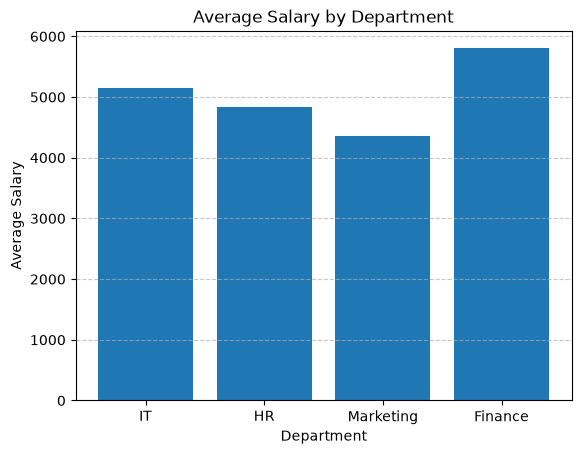

In [62]:
#visualize avg salary by department
plt.bar(merge_df["Department"], merge_df["Department Avg Salary"])
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()

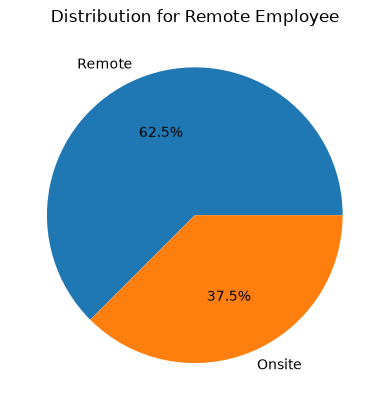

In [63]:
#view proportion remote vs onsite
remote_status = ["Remote", "Onsite"]
plt.pie(merge_df["Remote"].value_counts(), labels=remote_status, autopct="%1.1f%%")
plt.title("Distribution for Remote Employee")
plt.show()

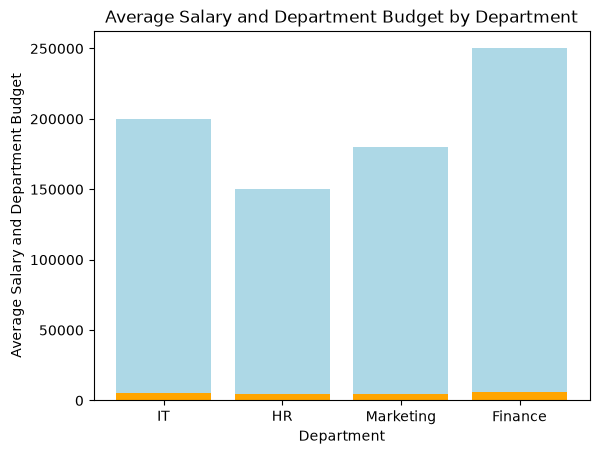

In [64]:
#visiualize stack chart for department average salary and department budget
plt.bar(merge_df["Department"], merge_df["Department Budget"], color="lightblue", label="Budget")
plt.bar(merge_df["Department"], merge_df["Department Avg Salary"], color="orange", label="Salary")
plt.title("Average Salary and Department Budget by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary and Department Budget")
plt.show()

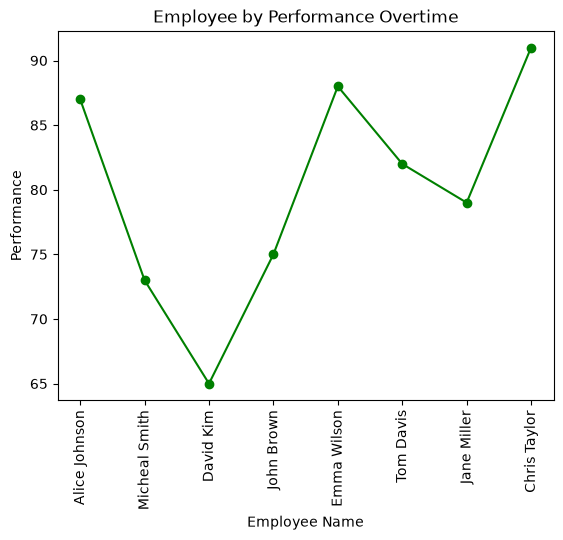

In [65]:
#visualize employee by performance overtime
plt.plot(merge_df["Full Name"], merge_df["Performance"], color="green", marker="o")
plt.title("Employee by Performance Overtime")
plt.xlabel("Employee Name")
plt.ylabel("Performance")
plt.xticks(rotation=90)
plt.show()

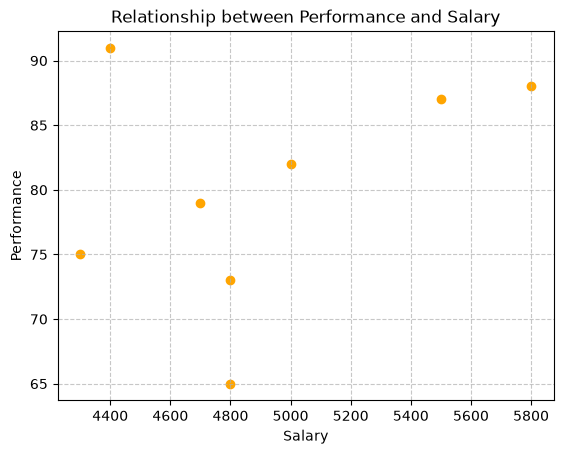

In [66]:
#visualising relationshop between performance and salary
plt.scatter(merge_df["Salary"], merge_df["Performance"], color="orange")
plt.title("Relationship between Performance and Salary")
plt.xlabel("Salary")
plt.grid(linestyle="--", alpha=0.7)
plt.ylabel("Performance")
plt.show()

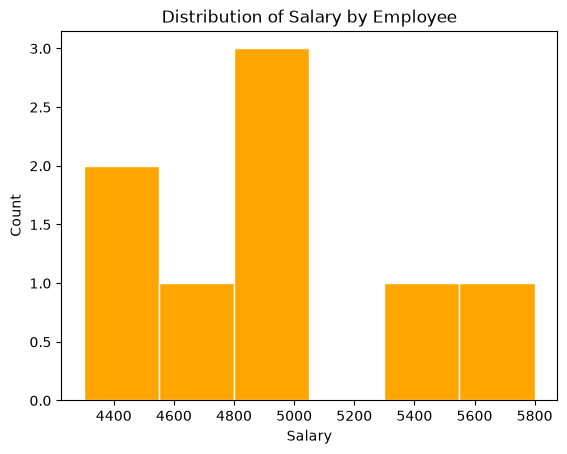

In [67]:
#visualize the distribution of salary by employee
plt.hist(merge_df["Salary"], bins=6, edgecolor="white", color="orange")
plt.title("Distribution of Salary by Employee")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

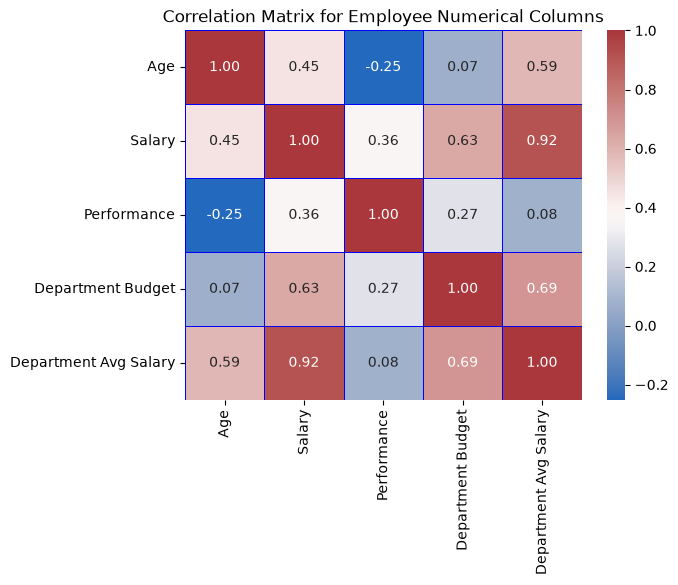

In [68]:
#visualize he correlation matrix for numerical cols
numerical_cols=["Age", "Salary", "Performance", "Department Budget", "Department Avg Salary"]
corr = merge_df[numerical_cols].corr()


sns.heatmap(corr, annot=True, cmap="vlag", fmt=".2f", linewidth="0.5", linecolor="blue")
plt.title("Correlation Matrix for Employee Numerical Columns")
plt.show()

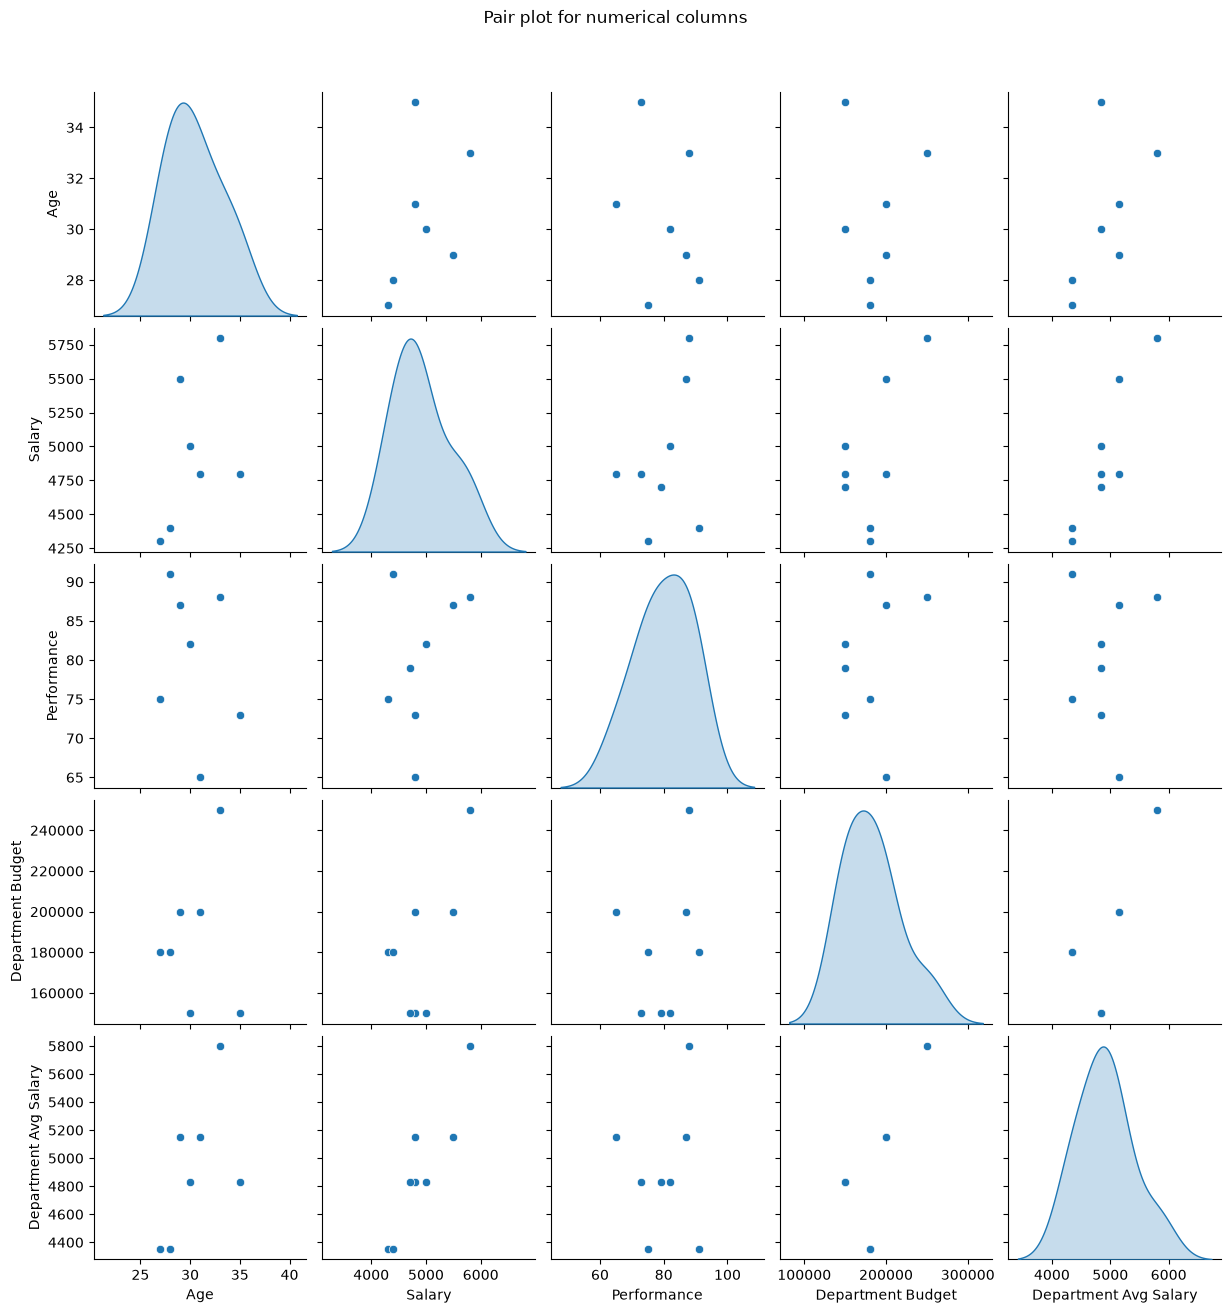

In [70]:
#visualize the correlation of employee numerical columns
sns.pairplot(merge_df[numerical_cols], diag_kind="kde")
plt.suptitle("Pair plot for numerical columns", y=1.05)
plt.show()

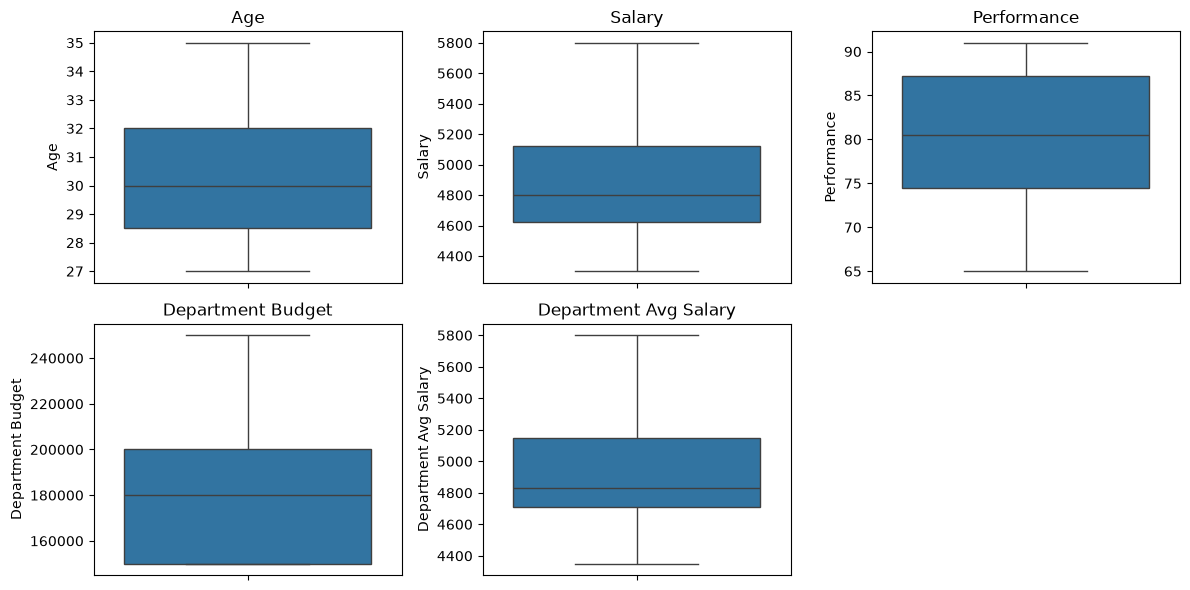

In [72]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=merge_df[col])
    plt.title(col)
    plt.tight_layout()
plt.show()

In [75]:
#detect outliers
Q1 = merge_df["Salary"].quantile(0.25)
Q3 = merge_df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bond = Q1 - 1.5 * IQR
upper_bond = Q3 + 1.5 * IQR

detect_outliers = (
    (merge_df["Salary"] < lower_bond) | (merge_df["Salary"] > upper_bond)
)

new_df = merge_df[
    (merge_df["Salary"] > lower_bond) & (merge_df["Salary"] < upper_bond)
    ]
new_df
print(detect_outliers.sum())
print(lower_bond)
print(upper_bond)

0
3874.8125
5875.3125


In [78]:
#distribution value for department using pie chart
dept_count = new_df["Department"].value_counts()
fig = px.pie(
    values=dept_counts.value,
    index=dept_counts.index,
)

NameError: name 'px' is not defined

In [79]:
#visualizing avg salary by dept
avg_salary = new_df.groupby("Department")["Salary"].mean().sort_values(ascending=False)
fig1 = px.bar(
    x=avg_salary.values,
    y=avg_salary.index,
    title="Average Salary By Department"
)

fig1.update_layout(
    xaxis_title="Average Salary",
    yaxis_title="Department"
)

fig1.show()

NameError: name 'px' is not defined

In [80]:
#distribution of employee performance

fig2 = px.histogram(
    new_df,
    x="Performance",
    nbins=6,
    title="Distribution Of Employee Performance"
)
fig2.update_traces(
    marker_line_color="white",
    marker_line_width = 1
)
fig2.show()

NameError: name 'px' is not defined

In [ ]:
fig3 = px.box(
    new_df,
    y="Salary",
    title="Boxplot Salary"
)
fig3.show()

In [81]:
fig4 = px.box(
    new_df,
    y="Department Budget",
    title="Boxplot Salary"
)
fig4.show()

NameError: name 'px' is not defined

In [82]:
new_df.to_csv("Employee_cleaned_dataset.csv")